In [15]:
# Import semua library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import joblib
warnings.filterwarnings('ignore')

# Setting visualisasi
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# load data set
df = pd.read_csv(r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\data\Movie Dataset.csv')
print(f"\nUkuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"\n5 data pertama:")
print(df.head())


Ukuran dataset: 9837 baris, 9 kolom

5 data pertama:
  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller

In [4]:
# data cleaning
df_clean = df.copy()

# Cek missing value awal
print("\nMissing value sebelum cleaning:")
print(df_clean.isnull().sum())

# Konversi tipe data
df_clean['Vote_Average'] = pd.to_numeric(df_clean['Vote_Average'], errors='coerce')
df_clean['Popularity'] = pd.to_numeric(df_clean['Popularity'], errors='coerce')
df_clean['Vote_Count'] = pd.to_numeric(df_clean['Vote_Count'], errors='coerce')

# Hapus baris dengan missing value di kolom penting
df_clean = df_clean.dropna(subset=['Title', 'Genre', 'Vote_Average'])
print(f"\nSetelah hapus missing value: {len(df_clean)} film")

# Isi Popularity yang kosong dengan median
df_clean['Popularity'] = df_clean['Popularity'].fillna(df_clean['Popularity'].median())
print(f"Popularity diisi dengan median: {df_clean['Popularity'].median():.2f}")

# Isi Vote_Count yang kosong dengan median
df_clean['Vote_Count'] = df_clean['Vote_Count'].fillna(df_clean['Vote_Count'].median())
print(f"Vote_Count diisi dengan median: {df_clean['Vote_Count'].median():.0f}")

# Isi Overview yang kosong dengan string kosong
df_clean['Overview'] = df_clean['Overview'].fillna('').astype(str)

# Ekstrak tahun dari Release_Date
df_clean['Year'] = pd.to_datetime(df_clean['Release_Date'], errors='coerce').dt.year
df_clean = df_clean.dropna(subset=['Year'])
df_clean['Year'] = df_clean['Year'].astype(int)
print(f"Ekstraksi tahun berhasil, rentang: {df_clean['Year'].min()} - {df_clean['Year'].max()}")

print(f"\nFinal dataset: {len(df_clean)} film, {df_clean.shape[1]} kolom")


Missing value sebelum cleaning:
Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

Setelah hapus missing value: 9826 film
Popularity diisi dengan median: 21.20
Vote_Count diisi dengan median: 444
Ekstraksi tahun berhasil, rentang: 1902 - 2024

Final dataset: 9826 film, 10 kolom


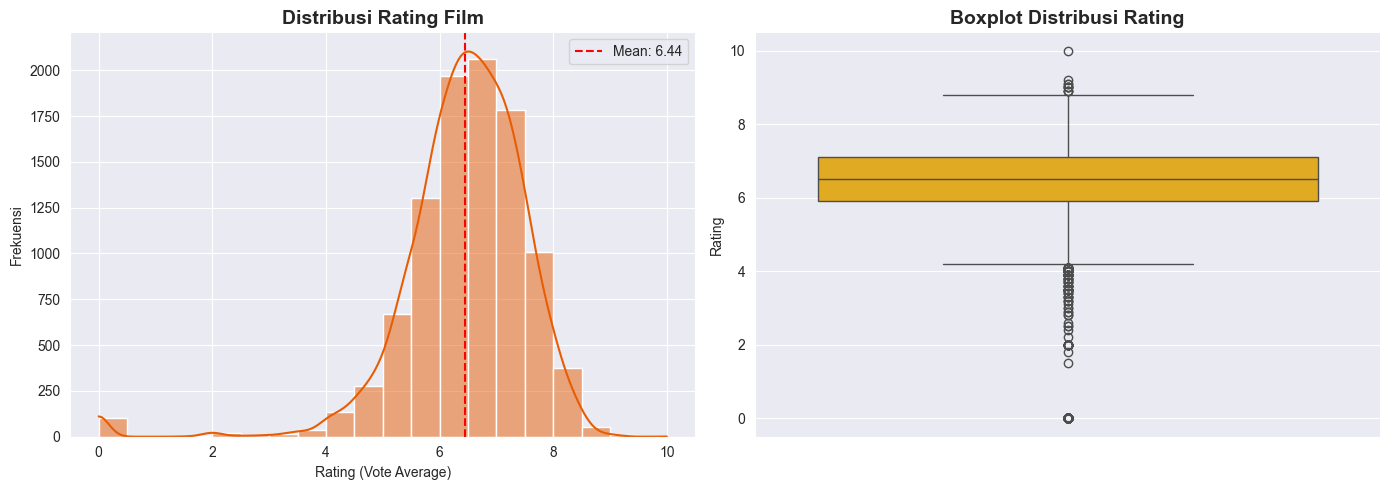


Statistik Rating:
- Rata-rata rating: 6.44
- Median rating: 6.50
- Rating tertinggi: 10.00
- Rating terendah: 0.00


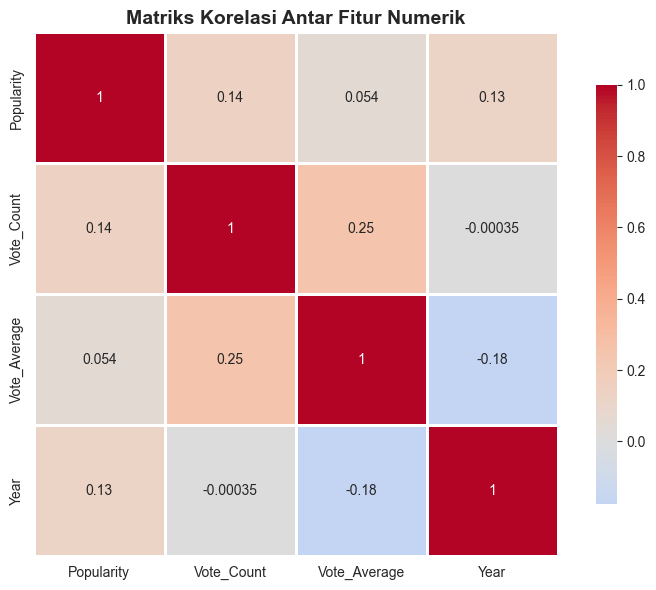


Interpretasi korelasi dengan Vote_Average:
- Popularity: Sangat lemah positif (0.054)
- Vote_Count: Lemah positif (0.254)
- Year: Lemah negatif (-0.175)


In [5]:
# EDA
# Distribusi rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.histplot(df_clean['Vote_Average'], bins=20, kde=True, color='#e85d04', ax=ax1)
ax1.set_title('Distribusi Rating Film', fontsize=14, fontweight='bold')
ax1.set_xlabel('Rating (Vote Average)')
ax1.set_ylabel('Frekuensi')
ax1.axvline(df_clean['Vote_Average'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df_clean["Vote_Average"].mean():.2f}')
ax1.legend()

ax2 = axes[1]
sns.boxplot(y=df_clean['Vote_Average'], color='#ffb703', ax=ax2)
ax2.set_title('Boxplot Distribusi Rating', fontsize=14, fontweight='bold')
ax2.set_ylabel('Rating')

plt.tight_layout()
plt.show()

print(f"\nStatistik Rating:")
print(f"- Rata-rata rating: {df_clean['Vote_Average'].mean():.2f}")
print(f"- Median rating: {df_clean['Vote_Average'].median():.2f}")
print(f"- Rating tertinggi: {df_clean['Vote_Average'].max():.2f}")
print(f"- Rating terendah: {df_clean['Vote_Average'].min():.2f}")

# Matriks korelasi
numeric_cols = ['Popularity', 'Vote_Count', 'Vote_Average', 'Year']
df_corr = df_clean[numeric_cols].copy()
correlation_matrix = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi Antar Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretasi korelasi dengan Vote_Average:")
for col in ['Popularity', 'Vote_Count', 'Year']:
    corr_value = correlation_matrix.loc[col, 'Vote_Average']
    if abs(corr_value) > 0.5:
        strength = "Kuat"
    elif abs(corr_value) > 0.3:
        strength = "Sedang"
    elif abs(corr_value) > 0.1:
        strength = "Lemah"
    else:
        strength = "Sangat lemah"
    
    direction = "positif" if corr_value > 0 else "negatif"
    print(f"- {col}: {strength} {direction} ({corr_value:.3f})")

In [6]:
# one hot encoding

# Pisahkan genre
df_clean['Genre_List'] = df_clean['Genre'].str.split(', ')

# Ambil semua genre unik
all_genres = set()
for genres in df_clean['Genre_List']:
    all_genres.update(genres)
all_genres = sorted(list(all_genres))
print(f"\nTotal genre unik: {len(all_genres)}")
print(f"Daftar genre: {', '.join(all_genres)}")

# One-Hot Encoding
for genre in all_genres:
    df_clean[f'genre_{genre}'] = df_clean['Genre_List'].apply(
        lambda x: 1 if genre in x else 0
    )
print(f"Ditambahkan {len(all_genres)} kolom genre baru")


Total genre unik: 19
Daftar genre: Action, Adventure, Animation, Comedy, Crime, Documentary, Drama, Family, Fantasy, History, Horror, Music, Mystery, Romance, Science Fiction, TV Movie, Thriller, War, Western
Ditambahkan 19 kolom genre baru


In [7]:
# menyiapkan fitur

# Fitur yang digunakan - SEKARANG DENGAN VOTE_COUNT
numeric_features = ['Popularity', 'Vote_Count', 'Year']
genre_features = [f'genre_{g}' for g in all_genres]

feature_cols = numeric_features + genre_features

print(f"\nFitur yang digunakan:")
print(f"- Numerik: {numeric_features}")
print(f"- Genre: {len(genre_features)} fitur")
print(f"- Total fitur: {len(feature_cols)}")

# Siapkan X dan y
X = df_clean[feature_cols].copy()
y = df_clean['Vote_Average'].copy()

# Isi nilai NaN jika masih ada
X = X.fillna(X.median())

print(f"\nShape data:")
print(f"- X shape: {X.shape}")
print(f"- y shape: {y.shape}")


Fitur yang digunakan:
- Numerik: ['Popularity', 'Vote_Count', 'Year']
- Genre: 19 fitur
- Total fitur: 22

Shape data:
- X shape: (9826, 22)
- y shape: (9826,)


In [8]:
# normalisasi dan split data

# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nPembagian data:")
print(f"- Data training: {len(X_train)} film ({len(X_train)/len(X)*100:.0f}%)")
print(f"- Data testing: {len(X_test)} film ({len(X_test)/len(X)*100:.0f}%)")


Pembagian data:
- Data training: 7860 film (80%)
- Data testing: 1966 film (20%)


In [9]:
# cross validation (sebelum tuning)
cv_scores = cross_val_score(RandomForestRegressor(random_state=42, n_jobs=-1), 
                            X_scaled, y, cv=5, scoring='r2')
print(f"\nCross-validation R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")


Cross-validation R²: 0.573 (+/- 0.042)


In [10]:
# training model default
rf_default = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train, y_train)

# Evaluasi model default
y_pred_default = rf_default.predict(X_test)
rmse_default = np.sqrt(mean_squared_error(y_test, y_pred_default))
r2_default = r2_score(y_test, y_pred_default)
accuracy_default = (abs(y_test - y_pred_default) <= 0.5).mean() * 100

print(f"\nEvaluasi Model Default:")
print(f"- RMSE: {rmse_default:.3f}")
print(f"- R² Score: {r2_default:.3f}")
print(f"- Akurasi (±0.5): {accuracy_default:.1f}%")



Evaluasi Model Default:
- RMSE: 0.682
- R² Score: 0.573
- Akurasi (±0.5): 58.0%


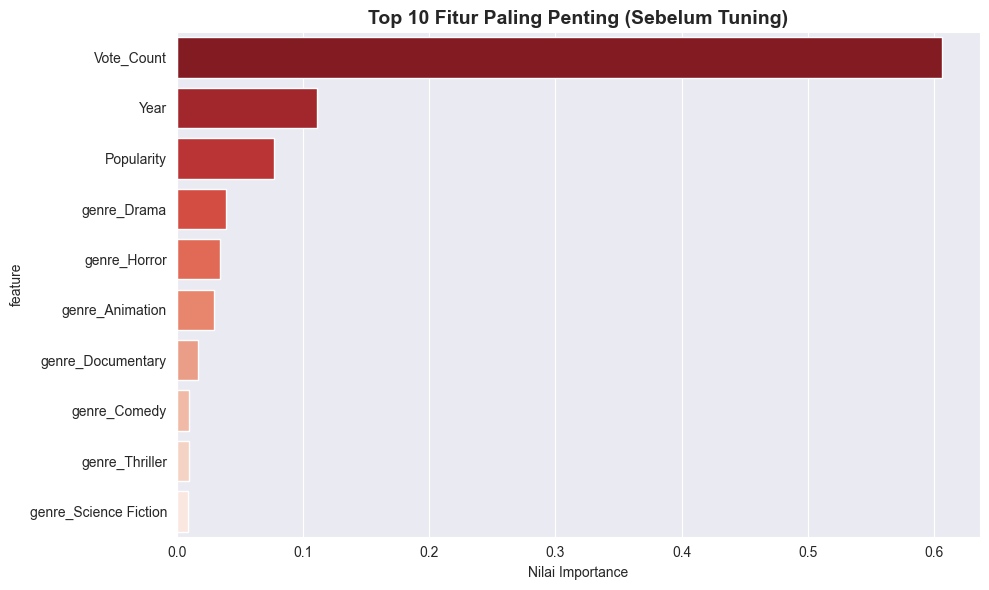


5 fitur terpenting:
   2. Vote_Count: 0.6062 (60.62%)
   3. Year: 0.1109 (11.09%)
   1. Popularity: 0.0773 (7.73%)
   10. genre_Drama: 0.0387 (3.87%)
   14. genre_Horror: 0.0341 (3.41%)


In [11]:
# feature importance (sebelum tuning)
importances = rf_default.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='importance', y='feature', palette='Reds_r')
plt.title('Top 10 Fitur Paling Penting (Sebelum Tuning)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.tight_layout()
plt.show()

print(f"\n5 fitur terpenting:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

In [12]:
# hyperparameter tuning (grid search)

# Definisikan parameter yang akan dicoba
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

print(f"\nMencoba {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])} kombinasi parameter...")
print(f"Setiap kombinasi diuji dengan 3-fold CV = {3 * 27} kali training")

# Grid search dengan cross-validation
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nParameter terbaik yang ditemukan:")
for param, value in grid_search.best_params_.items():
    print(f"- {param}: {value}")
print(f"- Best R² (CV): {grid_search.best_score_:.3f}")

# Gunakan model terbaik
best_rf = grid_search.best_estimator_



Mencoba 27 kombinasi parameter...
Setiap kombinasi diuji dengan 3-fold CV = 81 kali training
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Parameter terbaik yang ditemukan:
- max_depth: 15
- min_samples_split: 10
- n_estimators: 150
- Best R² (CV): 0.619


In [16]:
# evaluasi model setelah tuning
y_pred_best = best_rf.predict(X_test)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)
accuracy_best = (abs(y_test - y_pred_best) <= 0.5).mean() * 100

print(f"\nEvaluasi Model Setelah Tuning:")
print(f"- RMSE: {rmse_best:.3f}")
print(f"- R² Score: {r2_best:.3f}")
print(f"- Akurasi (±0.5): {accuracy_best:.1f}%")

print(f"\n📈 Perbandingan dengan model default:")
print(f"- R²: {r2_default:.3f} → {r2_best:.3f} (+{((r2_best - r2_default)/abs(r2_default)*100):.1f}%)")
print(f"- RMSE: {rmse_default:.3f} → {rmse_best:.3f} ({((rmse_default - rmse_best)/rmse_default*100):.1f}%)")



Evaluasi Model Setelah Tuning:
- RMSE: 0.681
- R² Score: 0.575
- Akurasi (±0.5): 58.5%

📈 Perbandingan dengan model default:
- R²: 0.573 → 0.575 (+0.3%)
- RMSE: 0.682 → 0.681 (0.2%)


In [17]:
# perbandingan dengan model lain
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest (Default)': rf_default,
    'Random Forest (Tuned)': best_rf
}

comparison_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    comparison_results.append({
        'Model': name,
        'R² Score': r2,
        'RMSE': rmse
    })
    print(f"   {name}: R²={r2:.3f}, RMSE={rmse:.3f}")

comparison_df = pd.DataFrame(comparison_results)
print("\nRingkasan Perbandingan:")
print(comparison_df.to_string(index=False))

   Linear Regression: R²=0.231, RMSE=0.915
   Random Forest (Default): R²=0.573, RMSE=0.682
   Random Forest (Tuned): R²=0.575, RMSE=0.681

Ringkasan Perbandingan:
                  Model  R² Score     RMSE
      Linear Regression  0.231439 0.915460
Random Forest (Default)  0.573193 0.682207
  Random Forest (Tuned)  0.575142 0.680647


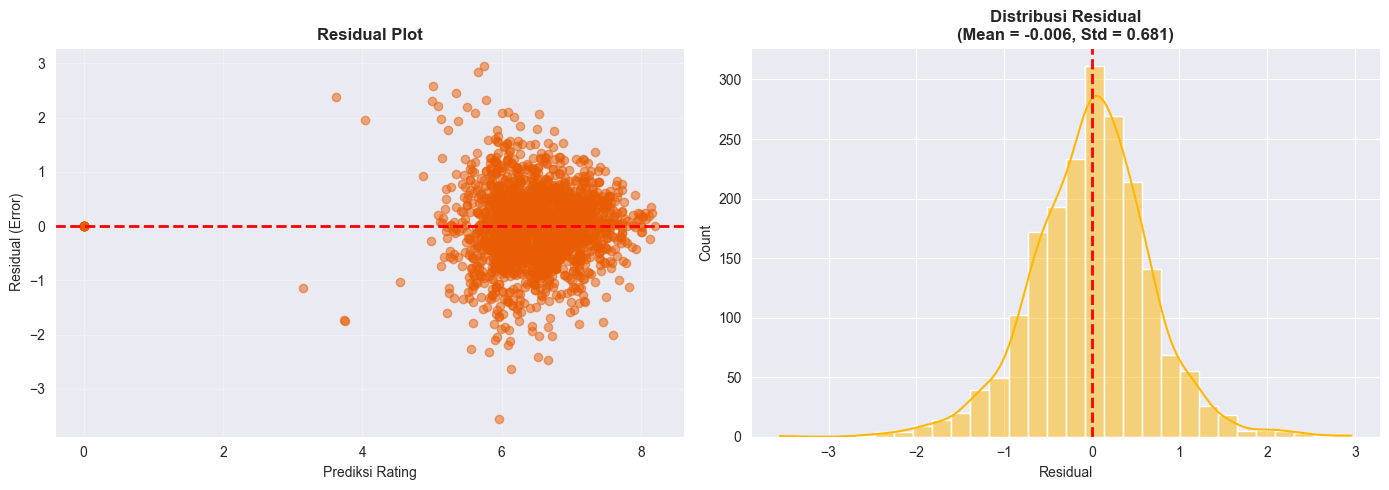


Analisis Residual:
- Mean residual: -0.006 (idealnya mendekati 0)
- Std residual: 0.681
- Model tidak bias (mean residual mendekati 0)


In [18]:
# residual plot (cek pola error)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(y_pred_best, residuals, alpha=0.5, color='#e85d04')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Prediksi Rating')
ax1.set_ylabel('Residual (Error)')
ax1.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
sns.histplot(residuals, kde=True, bins=30, color='#ffb703', ax=ax2)
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Residual')
ax2.set_title(f'Distribusi Residual\n(Mean = {residuals.mean():.3f}, Std = {residuals.std():.3f})', 
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nAnalisis Residual:")
print(f"- Mean residual: {residuals.mean():.3f} (idealnya mendekati 0)")
print(f"- Std residual: {residuals.std():.3f}")
if abs(residuals.mean()) < 0.05:
    print(f"- Model tidak bias (mean residual mendekati 0)")
else:
    print(f"- Model memiliki bias {residuals.mean():.3f}")


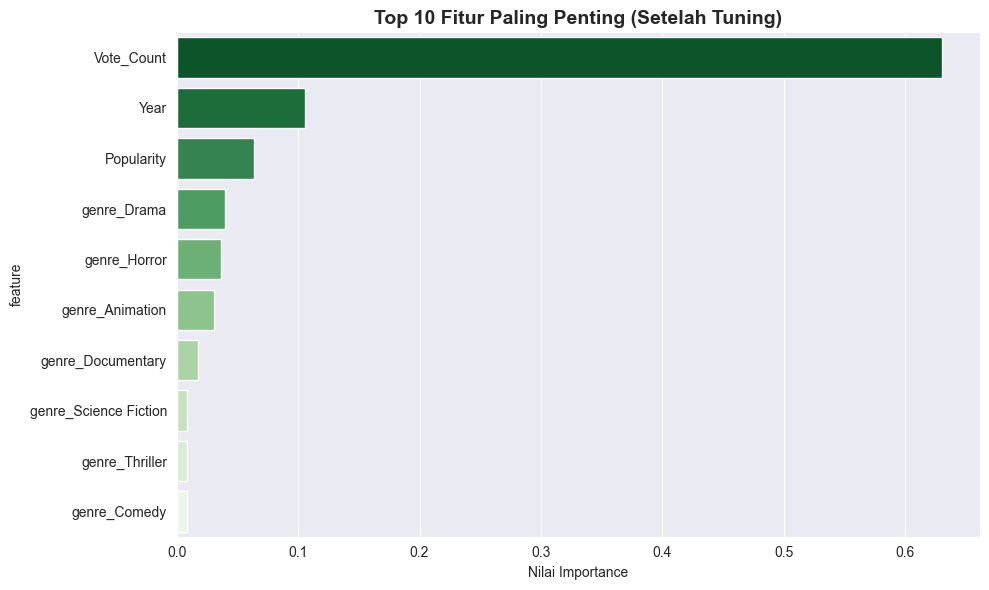


5 fitur terpenting (setelah tuning):
2. Vote_Count: 0.6303 (63.03%)
3. Year: 0.1058 (10.58%)
1. Popularity: 0.0633 (6.33%)
10. genre_Drama: 0.0394 (3.94%)
14. genre_Horror: 0.0367 (3.67%)


In [19]:
# feature importance (setelah tuning)
importances_tuned = best_rf.feature_importances_
feature_importance_tuned_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances_tuned
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_tuned_df.head(10), x='importance', y='feature', palette='Greens_r')
plt.title('Top 10 Fitur Paling Penting (Setelah Tuning)', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Importance')
plt.tight_layout()
plt.show()

print(f"\n5 fitur terpenting (setelah tuning):")
for i, row in feature_importance_tuned_df.head(5).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f} ({row['importance']*100:.2f}%)")

In [20]:
# simpan model

# Simpan model Random Forest terbaik
joblib.dump(best_rf, r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\models\rf_regressor.pkl')

# Simpan scaler
joblib.dump(scaler, r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\models\rf_scaler.pkl')

# Simpan daftar genre untuk frontend
with open(r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\models\genre_list.txt', 'w') as f:
    for genre in all_genres:
        f.write(f"{genre}\n")

# Simpan dataset yang sudah dibersihkan
df_clean.to_csv(r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\data\movies_cleaned.csv', index=False)

# Simpan feature columns untuk referensi
with open(r'C:\Users\Hp\Documents\coolyeah\sems 4\PASD\tubes2\models\feature_columns.txt', 'w') as f:
    for col in feature_cols:
        f.write(f"{col}\n")